In [1]:
import pandas as pd
import warnings 
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error as mse
from sklearn.metrics import mean_absolute_error as mae
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import warnings; warnings.filterwarnings("ignore")

In [2]:
churn_df = pd.read_csv('../Data/telecom_churn.csv')
churn_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [3]:
churn_df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
dem_home_owner_map = {'No':0, 'Yes': 1}
churn_df['Churn'] = churn_df['Churn'].map(dem_home_owner_map)

In [5]:
churn_df = pd.get_dummies(churn_df)

In [6]:
X = churn_df.drop("Churn", axis=1).values
y = churn_df["Churn"].values

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
knn = KNeighborsClassifier(n_neighbors=5)

# Fit the classifier to the training data
knn.fit(X_train, y_train)

# Print the accuracy
print(knn.score(X_test, y_test))

0.7672107877927609


In [7]:
y_pred = knn.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

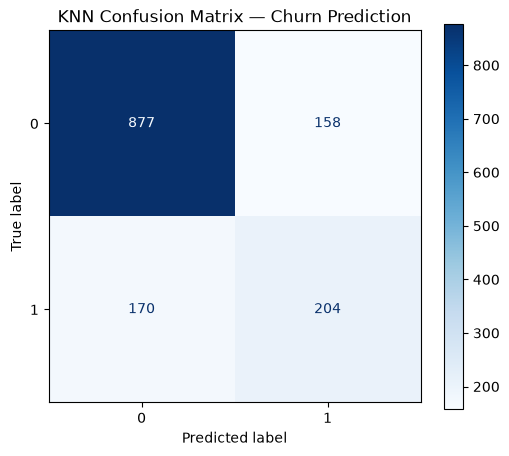

In [8]:
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=knn.classes_)
disp.plot(ax=ax, cmap='Blues')
ax.set_title('KNN Confusion Matrix — Churn Prediction')
plt.show()

In [9]:
model = RandomForestRegressor(n_estimators=50, random_state=1111)
model.fit(X_train, y_train)

# Create vectors of predictions
train_predictions = model.predict(X_train)
test_predictions = model.predict(X_test)

# Train/Test Errors
train_error = mae(y_true=y_train, y_pred=train_predictions)
test_error = mae(y_true=y_test, y_pred=test_predictions)

# Print the accuracy for seen and unseen data
print("Model error on seen data: {0:.2f}.".format(train_error))
print("Model error on unseen data: {0:.2f}.".format(test_error))

Model error on seen data: 0.08.
Model error on unseen data: 0.22.


In [10]:
rfr = RandomForestRegressor()
# Set the number of trees
rfr.n_estimators = 100

# Add a maximum depth
rfr.max_depth = 6

# Set the random state
rfr.random_state = 1111

In [11]:
rfc = RandomForestClassifier()

In [12]:
# Fit the rfc model. 
rfc.fit(X_train, y_train)

# Create arrays of predictions
classification_predictions = rfc.predict(X_test)
probability_predictions = rfc.predict_proba(X_test)

# Print out count of binary predictions
print(pd.Series(classification_predictions).value_counts())

# Print the first value from probability_predictions
print('The first predicted probabilities are: {}'.format(probability_predictions[0]))

0    1137
1     272
Name: count, dtype: int64
The first predicted probabilities are: [1. 0.]


In [13]:
rfc = RandomForestClassifier(n_estimators=50, max_depth=6, random_state=1111)

# Print the classification model
print(rfc)

# Print the classification model's random state parameter
print('The random state is: {}'.format(rfc.random_state))

# Print all parameters
print('Printing the parameters dictionary: {}'.format(rfc.get_params()))

RandomForestClassifier(max_depth=6, n_estimators=50, random_state=1111)
The random state is: 1111
Printing the parameters dictionary: {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 6, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 50, 'n_jobs': None, 'oob_score': False, 'random_state': 1111, 'verbose': 0, 'warm_start': False}


In [14]:
# Create a random forest classifier
rfc = RandomForestClassifier(n_estimators=50, max_depth=6, random_state=1111)

# Fit rfc using X_train and y_train
rfc.fit(X_train, y_train)

# Create predictions on X_test
predictions = rfc.predict(X_test)
print(predictions[0:5])

[0 0 0 0 0]


Based on the model predictions, the first five observations were predicted to have not churned.

In [15]:
# Print model accuracy using score() on the testing data
print(rfc.score(X_test, y_test))

0.7345635202271115


In [16]:
# Create dummy variables using pandas
X = pd.get_dummies(churn_df.drop(columns=['Churn']))
y = churn_df['Churn']

# Create training and testing datasets. Use 10% for the test set
X_train, X_test, y_train, y_test  = train_test_split(X, y, test_size=0.10, random_state=1111)

In [17]:
# Create temporary training and final testing datasets
X_temp, X_test, y_temp, y_test  =\
    train_test_split(X, y, test_size=0.2, random_state=1111)

# Create the final training and validation datasets
X_train, X_val, y_train, y_val =\
    train_test_split(X_temp, y_temp, test_size=0.25, random_state=1111)

In [18]:
# Manually calculate the MAE
n = len(predictions)
mae_one = sum(abs(y_test - predictions)) / n
print('With a manual calculation, the error is {}'.format(mae_one))

# Use scikit-learn to calculate the MAE
mae_two = mae(y_test, predictions)
print('Using scikit-learn, the error is {}'.format(mae_two))

With a manual calculation, the error is 0.255500354861604
Using scikit-learn, the error is 0.255500354861604


In [19]:
n = len(predictions)
# Finish the manual calculation of the MSE
mse_one = sum((y_test - predictions)**2) / n
print('With a manual calculation, the error is {}'.format(mse_one))

# Use the scikit-learn function to calculate MSE
mse_two = mse(y_test, predictions)
print('Using scikit-learn, the error is {}'.format(mse_two))

With a manual calculation, the error is 0.255500354861604
Using scikit-learn, the error is 0.255500354861604


# Sample Confusion Matrix

|  | Predicted: No Churn (0) | Predicted: Churn (1) |
|---|---|---|
| **Actual: No Churn (0)** | 850 (TN) | 95 (FP) |
| **Actual: Churn (1)** | 112 (FN) | 348 (TP) |

**Total = 1405**


**Results:**
- The overall accuracy is 0.85
- The precision is 0.79
- The recall is 0.76

In [20]:
# Calculate and print the accuracy
accuracy = (850 + 348) / (1405)
print("The overall accuracy is {0: 0.2f}".format(accuracy))

# Calculate and print the precision
precision = (348) / (348 + 95)
print("The precision is {0: 0.2f}".format(precision))

# Calculate and print the recall
recall = (348) / (112 + 348)
print("The recall is {0: 0.2f}".format(recall))

The overall accuracy is  0.85
The precision is  0.79
The recall is  0.76


In [21]:
# Create predictions
test_predictions = rfc.predict(X_test)

# Create and print the confusion matrix
cm = confusion_matrix(y_test, test_predictions)
print(cm)

# Print the true positives (actual 1s that were predicted 1s)
print("The number of true positives is: {}".format(cm[1, 1]))

[[1049    0]
 [ 360    0]]
The number of true positives is: 0


In [22]:
test_predictions = rfc.predict(X_test)

# Create precision or recall score based on the metric you imported
score = precision_score(y_test, test_predictions)

# Print the final result
print("The precision value is {0:.2f}".format(score))

The precision value is 0.00


In [23]:
test_scores, train_scores = [], []
for i in [1, 2, 3, 4, 5, 10, 20, 50]:
    rfc = RandomForestClassifier(n_estimators=i, random_state=1111)
    rfc.fit(X_train, y_train)
    # Create predictions for the X_train and X_test datasets.
    train_predictions = rfc.predict(X_train)
    test_predictions = rfc.predict(X_test)
    # Append the accuracy score for the test and train predictions.
    train_scores.append(round(accuracy_score(y_train, train_predictions), 2))
    test_scores.append(round(accuracy_score(y_test, test_predictions), 2))
# Print the train and test scores.
print("The training scores were: {}".format(train_scores))
print("The testing scores were: {}".format(test_scores))

The training scores were: [0.9, 0.9, 0.95, 0.95, 0.97, 0.98, 1.0, 1.0]
The testing scores were: [0.71, 0.75, 0.75, 0.76, 0.75, 0.77, 0.78, 0.79]


In [24]:
# Create neighbors
neighbors = np.arange(1, 13)
train_accuracies = {}
test_accuracies = {}

for neighbor in neighbors:
  
	# Set up a KNN Classifier
	knn = KNeighborsClassifier(n_neighbors=neighbor)
  
	# Fit the model
	knn.fit(X_train, y_train)
  
	# Compute accuracy
	train_accuracies[neighbor] = knn.score(X_train, y_train)
	test_accuracies[neighbor] = knn.score(X_test, y_test)
print(neighbors, '\n', train_accuracies, '\n', test_accuracies)

[ 1  2  3  4  5  6  7  8  9 10 11 12] 
 {1: 1.0, 2: 0.8783431952662721, 3: 0.874792899408284, 4: 0.8513609467455622, 5: 0.8480473372781065, 6: 0.8407100591715976, 7: 0.8307692307692308, 8: 0.8272189349112427, 9: 0.8229585798816568, 10: 0.8175147928994083, 11: 0.8134911242603551, 12: 0.8158579881656804} 
 {1: 0.7260468417317246, 2: 0.7686302342086586, 3: 0.7544357700496807, 4: 0.7764371894960965, 5: 0.758694109297374, 6: 0.7806955287437899, 7: 0.7828246983676366, 8: 0.7828246983676366, 9: 0.7814052519517388, 10: 0.7799858055358411, 11: 0.7821149751596878, 12: 0.78708303761533}


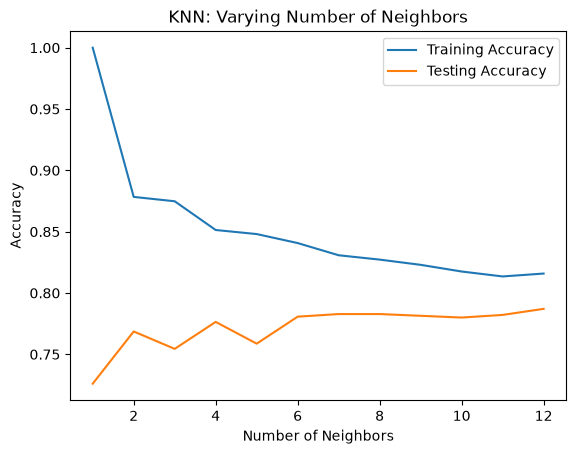

In [25]:
# Add a title
plt.title("KNN: Varying Number of Neighbors")

# Plot training accuracies
plt.plot(neighbors, train_accuracies.values(), label="Training Accuracy")

# Plot test accuracies
plt.plot(neighbors, test_accuracies.values(), label="Testing Accuracy")

plt.legend()
plt.xlabel("Number of Neighbors")
plt.ylabel("Accuracy")

# Display the plot
plt.show()

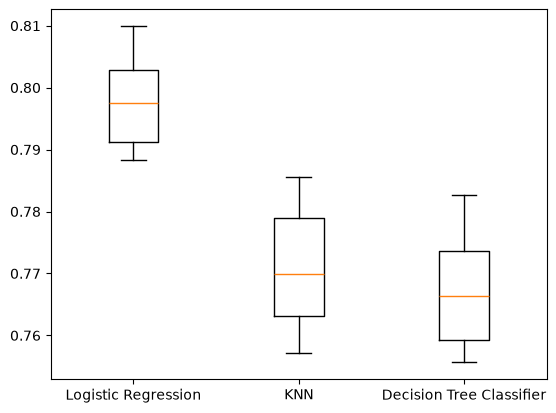

In [29]:
# Create models dictionary
models = {"Logistic Regression": LogisticRegression(), "KNN": KNeighborsClassifier(), "Decision Tree Classifier": DecisionTreeClassifier()}
results = []

# Loop through the models' values
for model in models.values():
  
  # Instantiate a KFold object
  kf = KFold(n_splits=6, random_state=12, shuffle=True)
  
  # Perform cross-validation
  cv_results = cross_val_score(model, X_train, y_train, cv=kf)
  results.append(cv_results)
plt.boxplot(results, tick_labels=models.keys())
plt.show()